In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.io import fits

%cd captures/

[Errno 2] No such file or directory: 'captures/'
/Users/lalyboyer/Desktop/software/captures


In [34]:
LINE = 600 # avaialbe: 200, 600, 1000
lamp_hgar = fits.open(f'LAMP_HGAR_lambda_ligne_{600}.fits')
lamp_ne = fits.open(f'LAMP_NE_lambda_ligne_{600}.fits')

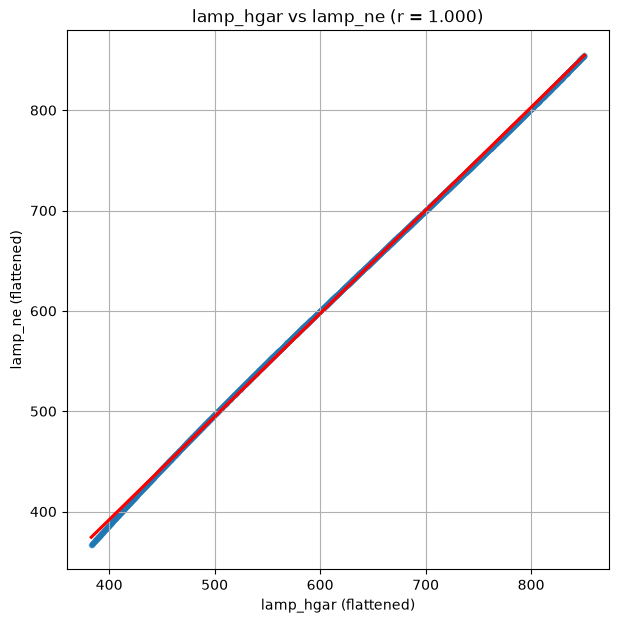

In [35]:
# extract data, flatten and align
data_hgar = np.asarray(lamp_hgar[0].data).ravel()
data_ne = np.asarray(lamp_ne[0].data).ravel()
n = min(data_hgar.size, data_ne.size)
x = data_hgar[:n]
y = data_ne[:n]

# remove non-finite values
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# optional subsample for performance
max_points = 200000
if x.size > max_points:
    idx = np.random.choice(x.size, max_points, replace=False)
    x = x[idx]
    y = y[idx]

# plot with seaborn and show Pearson r in title
r = np.corrcoef(x, y)[0, 1]
plt.figure(figsize=(7,7))
sns.regplot(x=x, y=y, scatter_kws={'s':10, 'alpha':0.4}, line_kws={'color':'red'})
plt.xlabel('lamp_hgar (flattened)')
plt.ylabel('lamp_ne (flattened)')
plt.title(f'lamp_hgar vs lamp_ne (r = {r:.3f})')
plt.grid(True)
plt.show()

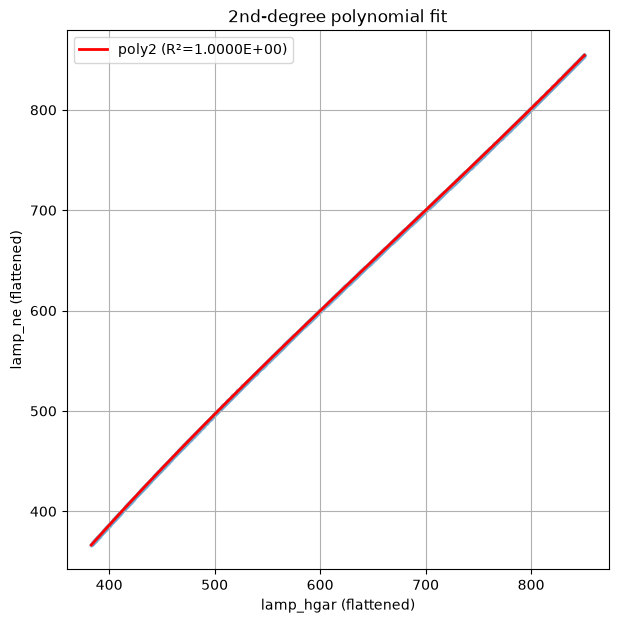

coeffs [a, b, c]: [ 7.25634937e-07 -1.45774083e-03  1.97429506e+00 -2.16699656e+02]
R^2: 0.9999996616537813


In [40]:
# fit 2nd-degree polynomial y = ax^2 + bx + c
coeffs = np.polyfit(x, y, 3)  # [a, b, c]
p = np.poly1d(coeffs)
y_pred = p(x)

# R^2
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

# plot
plt.figure(figsize=(7,7))
sns.scatterplot(x=x, y=y, s=10, alpha=0.4)
xs = np.linspace(x.min(), x.max(), 1000)
plt.plot(xs, p(xs), color='red', lw=2, label=f'poly2 (R²={r2:.4E})')
plt.xlabel('lamp_hgar (flattened)')
plt.ylabel('lamp_ne (flattened)')
plt.title('2nd-degree polynomial fit')
plt.legend()
plt.grid(True)
# plt.xlim(440,450)
# plt.ylim(440,450)
plt.show()

print('coeffs [a, b, c]:', coeffs)
print('R^2:', r2)
